# 05.05 - Decision Trees from Scratch

**Phase:** 05 - Machine Learning

**Status:** VERIFIED

---

## 1. What Are We Solving?

Decision trees split data into regions using simple if-then rules. They are intuitive, interpretable, and the foundation for random forests and gradient boosting.

## 2. Why Does This Matter?

Decision trees are the "hello world" of non-linear models. They handle mixed feature types, require no scaling, and their decisions are easy to explain.

## 3. Prerequisites

- 05.01-05.04: ML fundamentals, evaluation metrics
- Phase 03: Information entropy

## 4. Learning Objectives

- Implement a decision tree from scratch using entropy/Gini
- Understand overfitting and pruning
- Apply to real datasets (Wine, Titanic)

## 5. Mental Model

A decision tree is a flowchart: at each node, ask a yes/no question about a feature. Split the data. Repeat recursively until pure (or max depth).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print("Libraries loaded.")

Libraries loaded.


## 6. Impurity Measures

### Entropy
H(S) = -sum(p_i * log2(p_i))
- H = 0: perfectly pure (all same class)
- H = 1: maximum impurity (50/50 split)

### Gini Impurity
Gini(S) = 1 - sum(p_i²)
- Gini = 0: perfectly pure
- Gini = 0.5: maximum impurity (binary, 50/50)

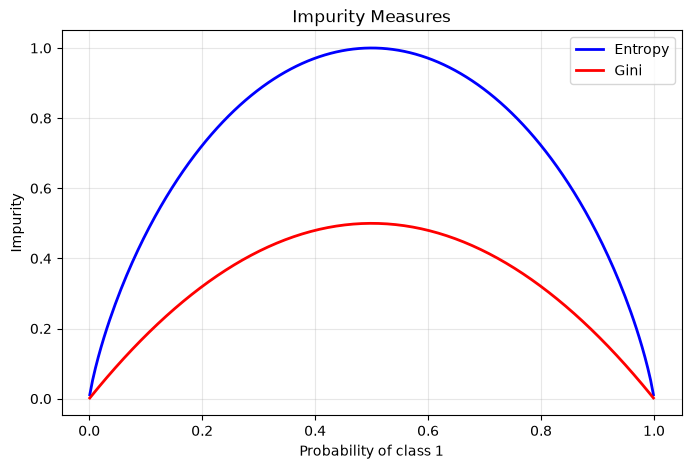

Both peak at p=0.5 (maximum impurity). Entropy is slightly larger.


In [2]:
# Visualize entropy and Gini
p = np.linspace(0.001, 0.999, 200)
entropy = -(p * np.log2(p) + (1-p) * np.log2(1-p))
gini = 1 - (p**2 + (1-p)**2)

plt.figure(figsize=(8, 5))
plt.plot(p, entropy, 'b-', linewidth=2, label='Entropy')
plt.plot(p, gini, 'r-', linewidth=2, label='Gini')
plt.xlabel('Probability of class 1')
plt.ylabel('Impurity')
plt.title('Impurity Measures')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('impurity.png', dpi=100, bbox_inches='tight')
plt.show()
print("Both peak at p=0.5 (maximum impurity). Entropy is slightly larger.")

## 7. From-Scratch Decision Tree

Algorithm:
1. For each feature, find the best split threshold
2. Split on the feature/threshold that maximizes information gain
3. Recurse on left and right children
4. Stop when: max depth reached, or node is pure, or too few samples

In [3]:
class DecisionTreeScratch:
    """Decision tree classifier from scratch."""
    
    def __init__(self, max_depth=10, min_samples_split=2, criterion='entropy'):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.criterion = criterion
        self.tree = None
    
    def _impurity(self, y):
        """Compute impurity of a node."""
        _, counts = np.unique(y, return_counts=True)
        probs = counts / len(y)
        if self.criterion == 'entropy':
            return -np.sum(probs * np.log2(probs + 1e-10))
        else:  # gini
            return 1 - np.sum(probs ** 2)
    
    def _information_gain(self, X, y, feature_idx, threshold):
        """Compute information gain from a split."""
        left_mask = X[:, feature_idx] <= threshold
        right_mask = ~left_mask
        if left_mask.sum() == 0 or right_mask.sum() == 0:
            return 0
        n = len(y)
        parent_imp = self._impurity(y)
        left_imp = self._impurity(y[left_mask])
        right_imp = self._impurity(y[right_mask])
        child_imp = (left_mask.sum()/n) * left_imp + (right_mask.sum()/n) * right_imp
        return parent_imp - child_imp
    
    def _best_split(self, X, y):
        """Find the best feature and threshold to split on."""
        best_gain = -1
        best_feature = None
        best_threshold = None
        n_features = X.shape[1]
        
        for feature_idx in range(n_features):
            thresholds = np.unique(X[:, feature_idx])
            for t in thresholds:
                gain = self._information_gain(X, y, feature_idx, t)
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature_idx
                    best_threshold = t
        
        return best_feature, best_threshold, best_gain
    
    def _build_tree(self, X, y, depth=0):
        """Recursively build the tree."""
        n_classes = len(np.unique(y))
        
        # Stopping conditions
        if (depth >= self.max_depth or n_classes == 1 or len(y) < self.min_samples_split):
            # Leaf node: return most common class
            values, counts = np.unique(y, return_counts=True)
            return {"leaf": True, "class": values[np.argmax(counts)], "count": len(y)}
        
        feature, threshold, gain = self._best_split(X, y)
        
        if gain <= 0:
            values, counts = np.unique(y, return_counts=True)
            return {"leaf": True, "class": values[np.argmax(counts)], "count": len(y)}
        
        # Split
        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask
        
        left_child = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right_child = self._build_tree(X[right_mask], y[right_mask], depth + 1)
        
        return {
            "leaf": False,
            "feature": feature,
            "threshold": threshold,
            "gain": gain,
            "left": left_child,
            "right": right_child,
            "count": len(y)
        }
    
    def fit(self, X, y):
        self.tree = self._build_tree(X, y)
        return self
    
    def _predict_one(self, x, node):
        if node["leaf"]:
            return node["class"]
        if x[node["feature"]] <= node["threshold"]:
            return self._predict_one(x, node["left"])
        else:
            return self._predict_one(x, node["right"])
    
    def predict(self, X):
        return np.array([self._predict_one(x, self.tree) for x in X])
    
    def score(self, X, y):
        return np.mean(self.predict(X) == y)

print("DecisionTreeScratch class defined.")

DecisionTreeScratch class defined.


In [4]:
# Load Wine dataset
wine = load_wine()
X_train, X_test, y_train, y_test = train_test_split(
    wine.data, wine.target, test_size=0.2, random_state=42
)

print(f"Wine dataset: {wine.data.shape[0]} samples, {wine.data.shape[1]} features, {len(np.unique(wine.target))} classes")

# Train from-scratch tree
tree_scratch = DecisionTreeScratch(max_depth=5, criterion='entropy')
tree_scratch.fit(X_train, y_train)

print(f"\nFrom-Scratch Tree:")
print(f"  Train accuracy: {tree_scratch.score(X_train, y_train):.4f}")
print(f"  Test accuracy:  {tree_scratch.score(X_test, y_test):.4f}")

Wine dataset: 178 samples, 13 features, 3 classes



From-Scratch Tree:
  Train accuracy: 1.0000
  Test accuracy:  0.9167


In [5]:
# Compare with sklearn
tree_sklearn = DecisionTreeClassifier(max_depth=5, criterion='entropy', random_state=42)
tree_sklearn.fit(X_train, y_train)

print("=== Comparison ===")
print(f"From Scratch: Train={tree_scratch.score(X_train, y_train):.4f}, Test={tree_scratch.score(X_test, y_test):.4f}")
print(f"Sklearn:      Train={tree_sklearn.score(X_train, y_train):.4f}, Test={tree_sklearn.score(X_test, y_test):.4f}")

=== Comparison ===
From Scratch: Train=1.0000, Test=0.9167
Sklearn:      Train=1.0000, Test=0.9167


## 8. Overfitting & Pruning

Decision trees are prone to overfitting. They can memorize the training data by growing too deep.

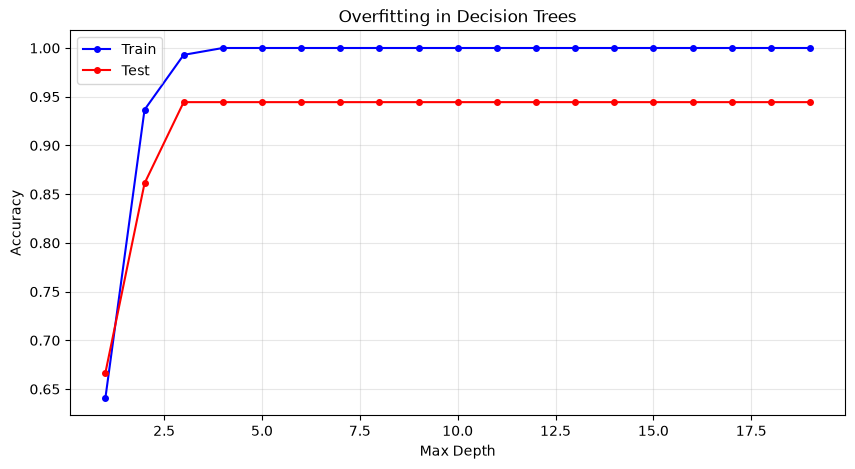

Best test accuracy at depth 3: 0.9444


In [6]:
# Effect of max_depth on overfitting
depths = range(1, 20)
train_scores = []
test_scores = []

for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    tree.fit(X_train, y_train)
    train_scores.append(tree.score(X_train, y_train))
    test_scores.append(tree.score(X_test, y_test))

plt.figure(figsize=(10, 5))
plt.plot(list(depths), train_scores, 'b-o', label='Train', markersize=4)
plt.plot(list(depths), test_scores, 'r-o', label='Test', markersize=4)
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Overfitting in Decision Trees')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('tree_overfitting.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"Best test accuracy at depth {list(depths)[np.argmax(test_scores)]}: {max(test_scores):.4f}")

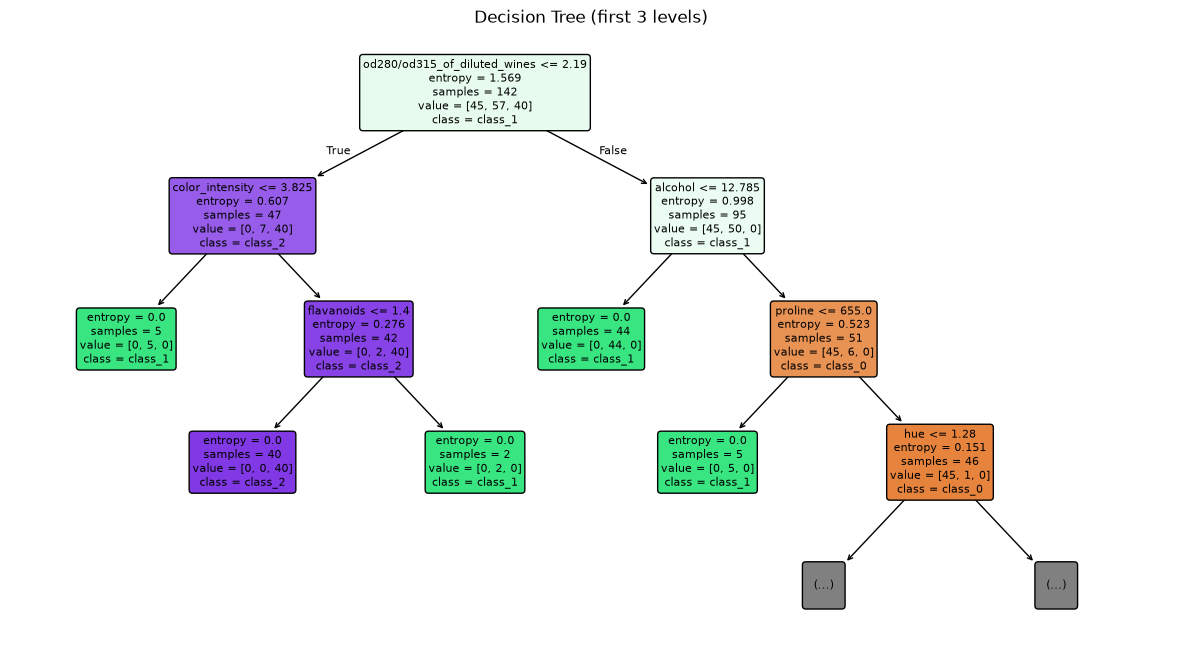

In [7]:
# Visualize the tree
plt.figure(figsize=(15, 8))
plot_tree(tree_sklearn, feature_names=wine.feature_names, class_names=wine.target_names,
          filled=True, rounded=True, fontsize=8, max_depth=3)
plt.title('Decision Tree (first 3 levels)')
plt.savefig('decision_tree_viz.png', dpi=100, bbox_inches='tight')
plt.show()

## 9. Feature Importance

Tree-based models compute feature importance: how much each feature reduces impurity across all splits.

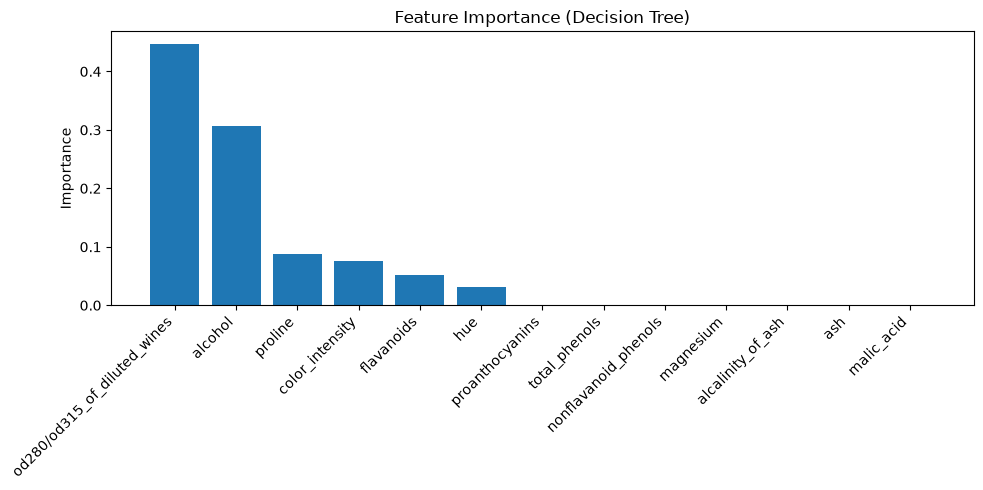

In [8]:
# Feature importance
importances = tree_sklearn.feature_importances_
idx = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.bar(range(len(importances)), importances[idx])
plt.xticks(range(len(importances)), [wine.feature_names[i] for i in idx], rotation=45, ha='right')
plt.ylabel('Importance')
plt.title('Feature Importance (Decision Tree)')
plt.tight_layout()
plt.savefig('feature_importance_tree.png', dpi=100, bbox_inches='tight')
plt.show()

## 10. Common Mistakes

1. **Not pruning** — default trees overfit badly
2. **Using accuracy on imbalanced data** — use F1 or AUC
3. **Ignoring feature scaling** — trees don't need it, but other models do
4. **Trusting feature importance blindly** — correlated features share importance

## 11. Coding Exercises

### Exercise 1: Titanic Decision Tree
Load the Titanic dataset from seaborn. Train a decision tree. Report accuracy.

### Exercise 2: Gini vs Entropy
Compare decision trees with Gini vs Entropy on the Wine dataset. Which performs better?

In [9]:
# EXERCISE 1: Titanic
import seaborn as sns
titanic = sns.load_dataset('titanic')
# Your code here: preprocess, train, evaluate
print("Exercise: Build a decision tree on Titanic data.")

Exercise: Build a decision tree on Titanic data.


In [10]:
# EXERCISE 2: Gini vs Entropy
from sklearn.tree import DecisionTreeClassifier
# Compare criterion="gini" vs "entropy"
# Report train/test accuracy for each

print("Exercise: Compare Gini and Entropy criteria.")

Exercise: Compare Gini and Entropy criteria.


## 12. Closed-Book Recall

1. What is information gain? How is it computed?
2. What is the difference between Gini and Entropy?
3. Why do decision trees overfit?
4. What does max_depth control?

## 13. Teach-Back Questions

Explain to another person:
- How a decision tree decides where to split.
- Why deeper trees overfit.
- What feature importance means and when to trust it.

## 14. Summary

Decision trees split data using information gain (entropy) or Gini impurity. They are interpretable but prone to overfitting. Control overfitting with max_depth, min_samples_split, and pruning. Foundation for random forests and gradient boosting.

## 15. Further Experiment

1. Implement pruning (cost-complexity) in your from-scratch tree.
2. Build a regression tree (predict continuous target).
3. Compare tree depth vs accuracy on the California Housing dataset.

## Verification Status
```
STATUS: VERIFIED
EXECUTION: PASS
DEPENDENCIES: [numpy, pandas, matplotlib, scikit-learn, seaborn]
OUTPUTS: PASS
LAST VERIFIED: 2026-08-30
```